In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("AI_Impact_on_Jobs_2030.csv")
df.head()

,Employee_ID,Job_Title,Industry,Country,Education_Level,Years_Experience,AI_Replacement_Risk,Future_Demand_Score,Remote_Work_Possibility,Average_Salary_USD,Required_Skills,Automation_Level,Job_Growth_2030,Work_Hours_Per_Week,Company_Size,AI_Tool_Usage,Performance_Score,Upskilling_Needed,Job_Satisfaction,Hiring_Trend_2026
0,AIJ-100000,Data Engineer,Healthcare,Japan,PhD,1,0.25,0.78,Yes,207392,"Python, Communication, Deep Learning",Low,3,37,Enterprise,High,2.08,Yes,3.86,Growing
1,AIJ-100001,Healthcare Analyst,Retail,UK,Bachelor,24,0.73,0.33,No,140785,"Deep Learning, Azure, Communication, TensorFlo...",Low,-5,42,Startup,Moderate,4.54,No,4.23,Growing
2,AIJ-100002,HR Specialist,Education,Canada,High School,21,0.80,0.69,Yes,124800,"Kubernetes, Cloud Computing, TensorFlow, SQL, ...",Medium,-5,57,Startup,Low,3.14,No,3.54,Stable
3,AIJ-100003,Cybersecurity Analyst,Government,UK,Bachelor,5,0.29,0.94,No,199878,"Excel, Kubernetes, Prompt Engineering, Leadership",Medium,7,59,Enterprise,High,3.67,No,4.37,Declining
4,AIJ-100004,Healthcare Analyst,Education,UAE,PhD,20,0.11,0.92,No,178682,"SQL, Leadership, TensorFlow, Cybersecurity",Low,6,34,Startup,High,3.68,No,3.99,Stable


In [3]:
df.drop(['Employee_ID', 'Remote_Work_Possibility', 'Work_Hours_Per_Week'], axis = 1, inplace = True)
df.head()

,Job_Title,Industry,Country,Education_Level,Years_Experience,AI_Replacement_Risk,Future_Demand_Score,Average_Salary_USD,Required_Skills,Automation_Level,Job_Growth_2030,Company_Size,AI_Tool_Usage,Performance_Score,Upskilling_Needed,Job_Satisfaction,Hiring_Trend_2026
0,Data Engineer,Healthcare,Japan,PhD,1,0.25,0.78,207392,"Python, Communication, Deep Learning",Low,3,Enterprise,High,2.08,Yes,3.86,Growing
1,Healthcare Analyst,Retail,UK,Bachelor,24,0.73,0.33,140785,"Deep Learning, Azure, Communication, TensorFlo...",Low,-5,Startup,Moderate,4.54,No,4.23,Growing
2,HR Specialist,Education,Canada,High School,21,0.80,0.69,124800,"Kubernetes, Cloud Computing, TensorFlow, SQL, ...",Medium,-5,Startup,Low,3.14,No,3.54,Stable
3,Cybersecurity Analyst,Government,UK,Bachelor,5,0.29,0.94,199878,"Excel, Kubernetes, Prompt Engineering, Leadership",Medium,7,Enterprise,High,3.67,No,4.37,Declining
4,Healthcare Analyst,Education,UAE,PhD,20,0.11,0.92,178682,"SQL, Leadership, TensorFlow, Cybersecurity",Low,6,Startup,High,3.68,No,3.99,Stable


In [4]:
df.isnull().sum()

Job_Title              0
Industry               0
Country                0
Education_Level        0
Years_Experience       0
AI_Replacement_Risk    0
Future_Demand_Score    0
Average_Salary_USD     0
Required_Skills        0
Automation_Level       0
Job_Growth_2030        0
Company_Size           0
AI_Tool_Usage          0
Performance_Score      0
Upskilling_Needed      0
Job_Satisfaction       0
Hiring_Trend_2026      0
dtype: int64

In [5]:
df.describe()

,Years_Experience,AI_Replacement_Risk,Future_Demand_Score,Average_Salary_USD,Job_Growth_2030,Performance_Score,Job_Satisfaction
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,12.383000,0.502910,0.601203,126641.746667,17.238333,3.514643,3.026167
std,7.528958,0.261293,0.226674,55405.053057,16.230322,0.873375,1.146361
min,0.000000,0.050000,0.200000,30221.000000,-10.000000,2.000000,1.000000
25%,6.000000,0.280000,0.420000,77262.000000,3.000000,2.760000,2.060000
50%,12.000000,0.500000,0.600000,127660.500000,17.000000,3.540000,3.025000
75%,19.000000,0.730000,0.800000,174811.750000,31.000000,4.270000,4.010000
max,25.000000,0.950000,0.990000,219998.000000,45.000000,5.000000,5.000000


In [6]:
df.head()

,Job_Title,Industry,Country,Education_Level,Years_Experience,AI_Replacement_Risk,Future_Demand_Score,Average_Salary_USD,Required_Skills,Automation_Level,Job_Growth_2030,Company_Size,AI_Tool_Usage,Performance_Score,Upskilling_Needed,Job_Satisfaction,Hiring_Trend_2026
0,Data Engineer,Healthcare,Japan,PhD,1,0.25,0.78,207392,"Python, Communication, Deep Learning",Low,3,Enterprise,High,2.08,Yes,3.86,Growing
1,Healthcare Analyst,Retail,UK,Bachelor,24,0.73,0.33,140785,"Deep Learning, Azure, Communication, TensorFlo...",Low,-5,Startup,Moderate,4.54,No,4.23,Growing
2,HR Specialist,Education,Canada,High School,21,0.80,0.69,124800,"Kubernetes, Cloud Computing, TensorFlow, SQL, ...",Medium,-5,Startup,Low,3.14,No,3.54,Stable
3,Cybersecurity Analyst,Government,UK,Bachelor,5,0.29,0.94,199878,"Excel, Kubernetes, Prompt Engineering, Leadership",Medium,7,Enterprise,High,3.67,No,4.37,Declining
4,Healthcare Analyst,Education,UAE,PhD,20,0.11,0.92,178682,"SQL, Leadership, TensorFlow, Cybersecurity",Low,6,Startup,High,3.68,No,3.99,Stable


In [7]:
df['Hiring_Trend_2026'].unique()

array(['Growing', 'Stable', 'Declining'], dtype=object)

In [8]:
# Convert ['Growing', 'Stable', 'Declining'] into 0, 1, 2 respectively.

mapping = {
    'Growing': 0,
    'Stable': 1,
    'Declining': 2
}

df['Hiring_Trend_2026'] = df['Hiring_Trend_2026'].map(mapping)

df.head()

,Job_Title,Industry,Country,Education_Level,Years_Experience,AI_Replacement_Risk,Future_Demand_Score,Average_Salary_USD,Required_Skills,Automation_Level,Job_Growth_2030,Company_Size,AI_Tool_Usage,Performance_Score,Upskilling_Needed,Job_Satisfaction,Hiring_Trend_2026
0,Data Engineer,Healthcare,Japan,PhD,1,0.25,0.78,207392,"Python, Communication, Deep Learning",Low,3,Enterprise,High,2.08,Yes,3.86,0
1,Healthcare Analyst,Retail,UK,Bachelor,24,0.73,0.33,140785,"Deep Learning, Azure, Communication, TensorFlo...",Low,-5,Startup,Moderate,4.54,No,4.23,0
2,HR Specialist,Education,Canada,High School,21,0.80,0.69,124800,"Kubernetes, Cloud Computing, TensorFlow, SQL, ...",Medium,-5,Startup,Low,3.14,No,3.54,1
3,Cybersecurity Analyst,Government,UK,Bachelor,5,0.29,0.94,199878,"Excel, Kubernetes, Prompt Engineering, Leadership",Medium,7,Enterprise,High,3.67,No,4.37,2
4,Healthcare Analyst,Education,UAE,PhD,20,0.11,0.92,178682,"SQL, Leadership, TensorFlow, Cybersecurity",Low,6,Startup,High,3.68,No,3.99,1


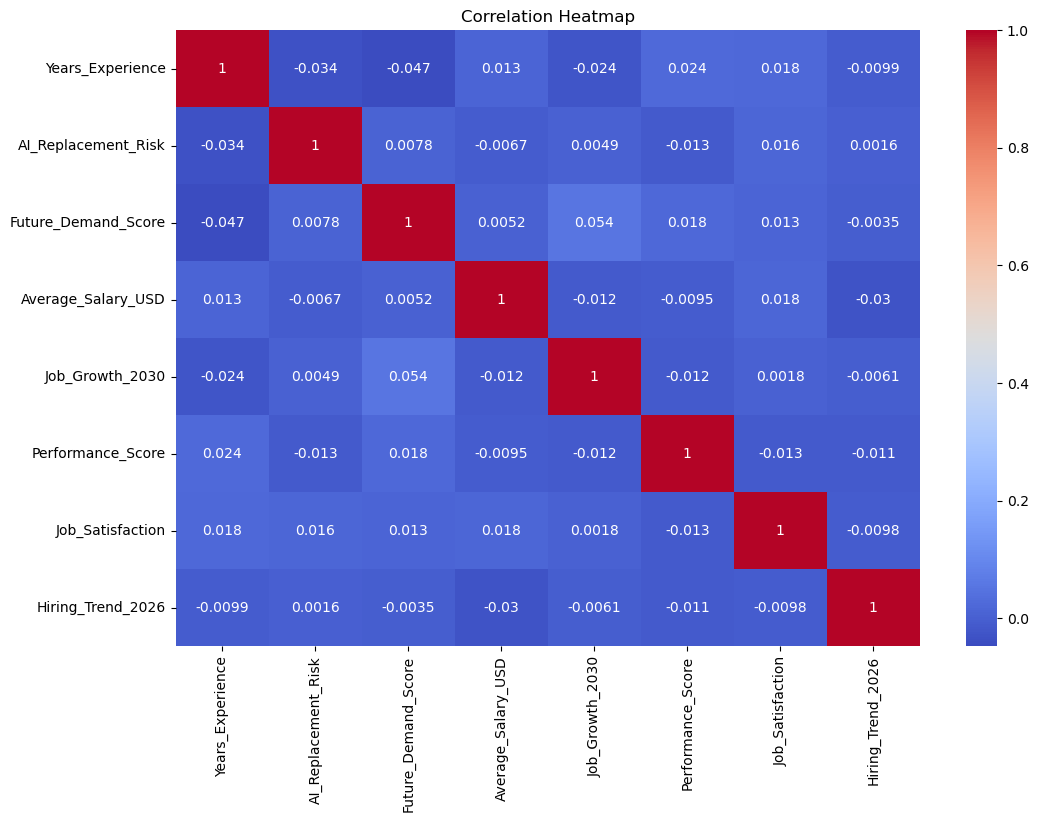

In [9]:
# Heat Map

plt.figure(figsize = (12, 8))
sns.heatmap(df.corr(numeric_only = True), annot = True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

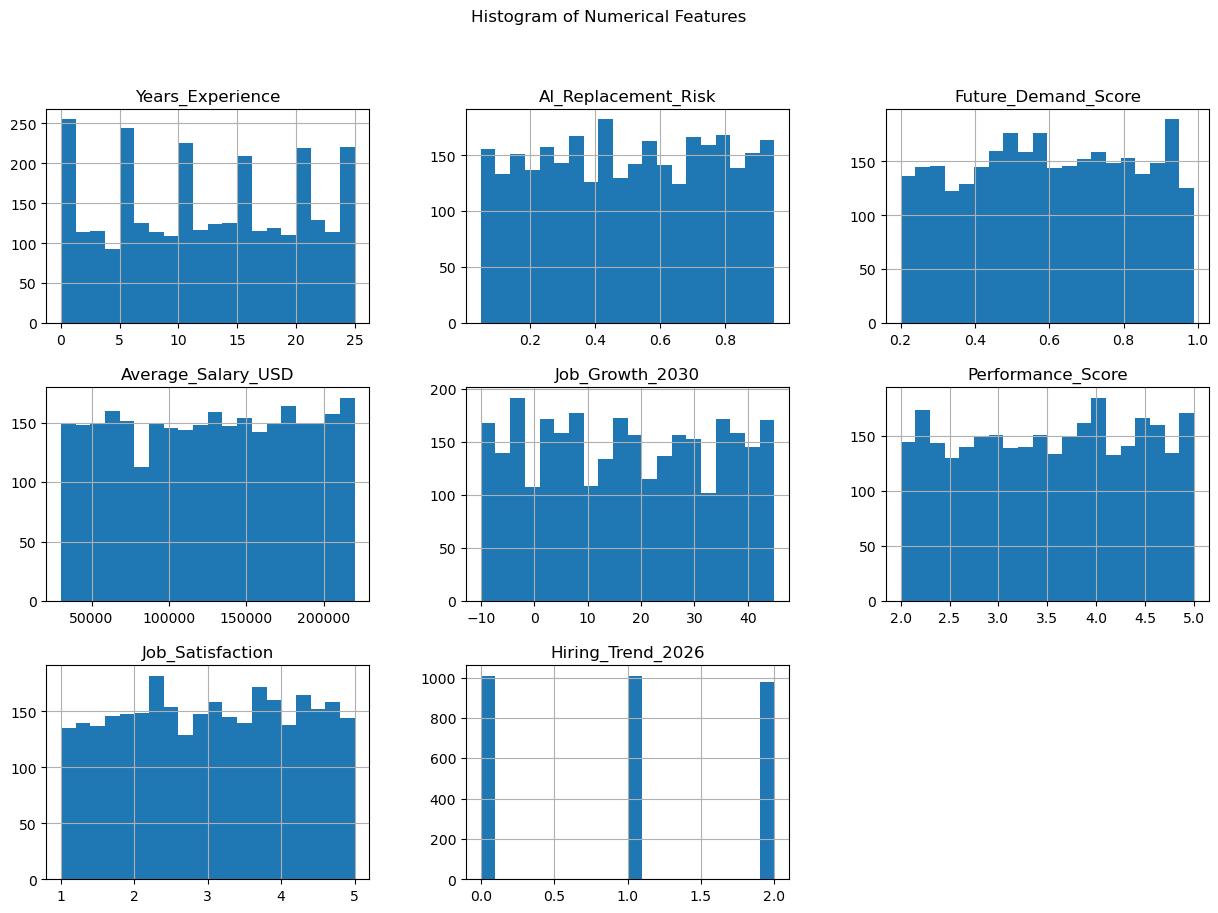

In [10]:
# Histogram

df.hist(figsize=(15,10), bins=20)
plt.suptitle("Histogram of Numerical Features")
plt.show()

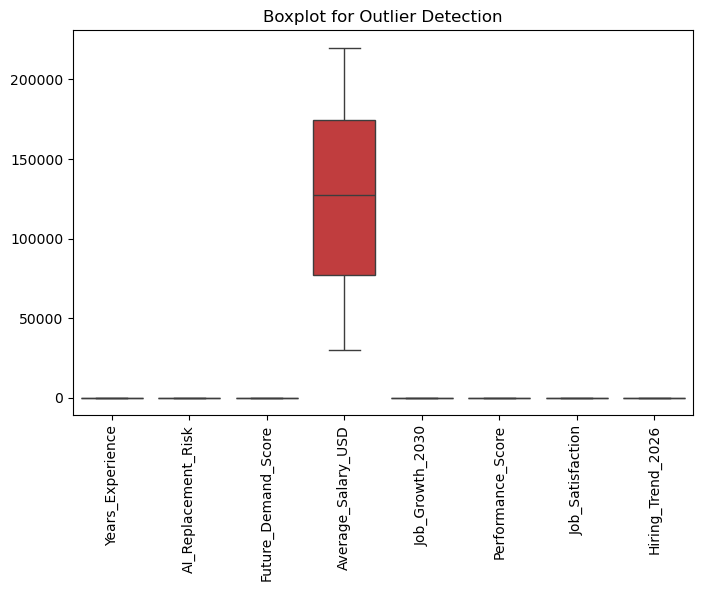

In [11]:
# Count Plot

plt.figure(figsize=(8, 5))
sns.boxplot(data=df.select_dtypes(include = 'number'))
plt.xticks(rotation=90)
plt.title("Boxplot for Outlier Detection")
plt.show()

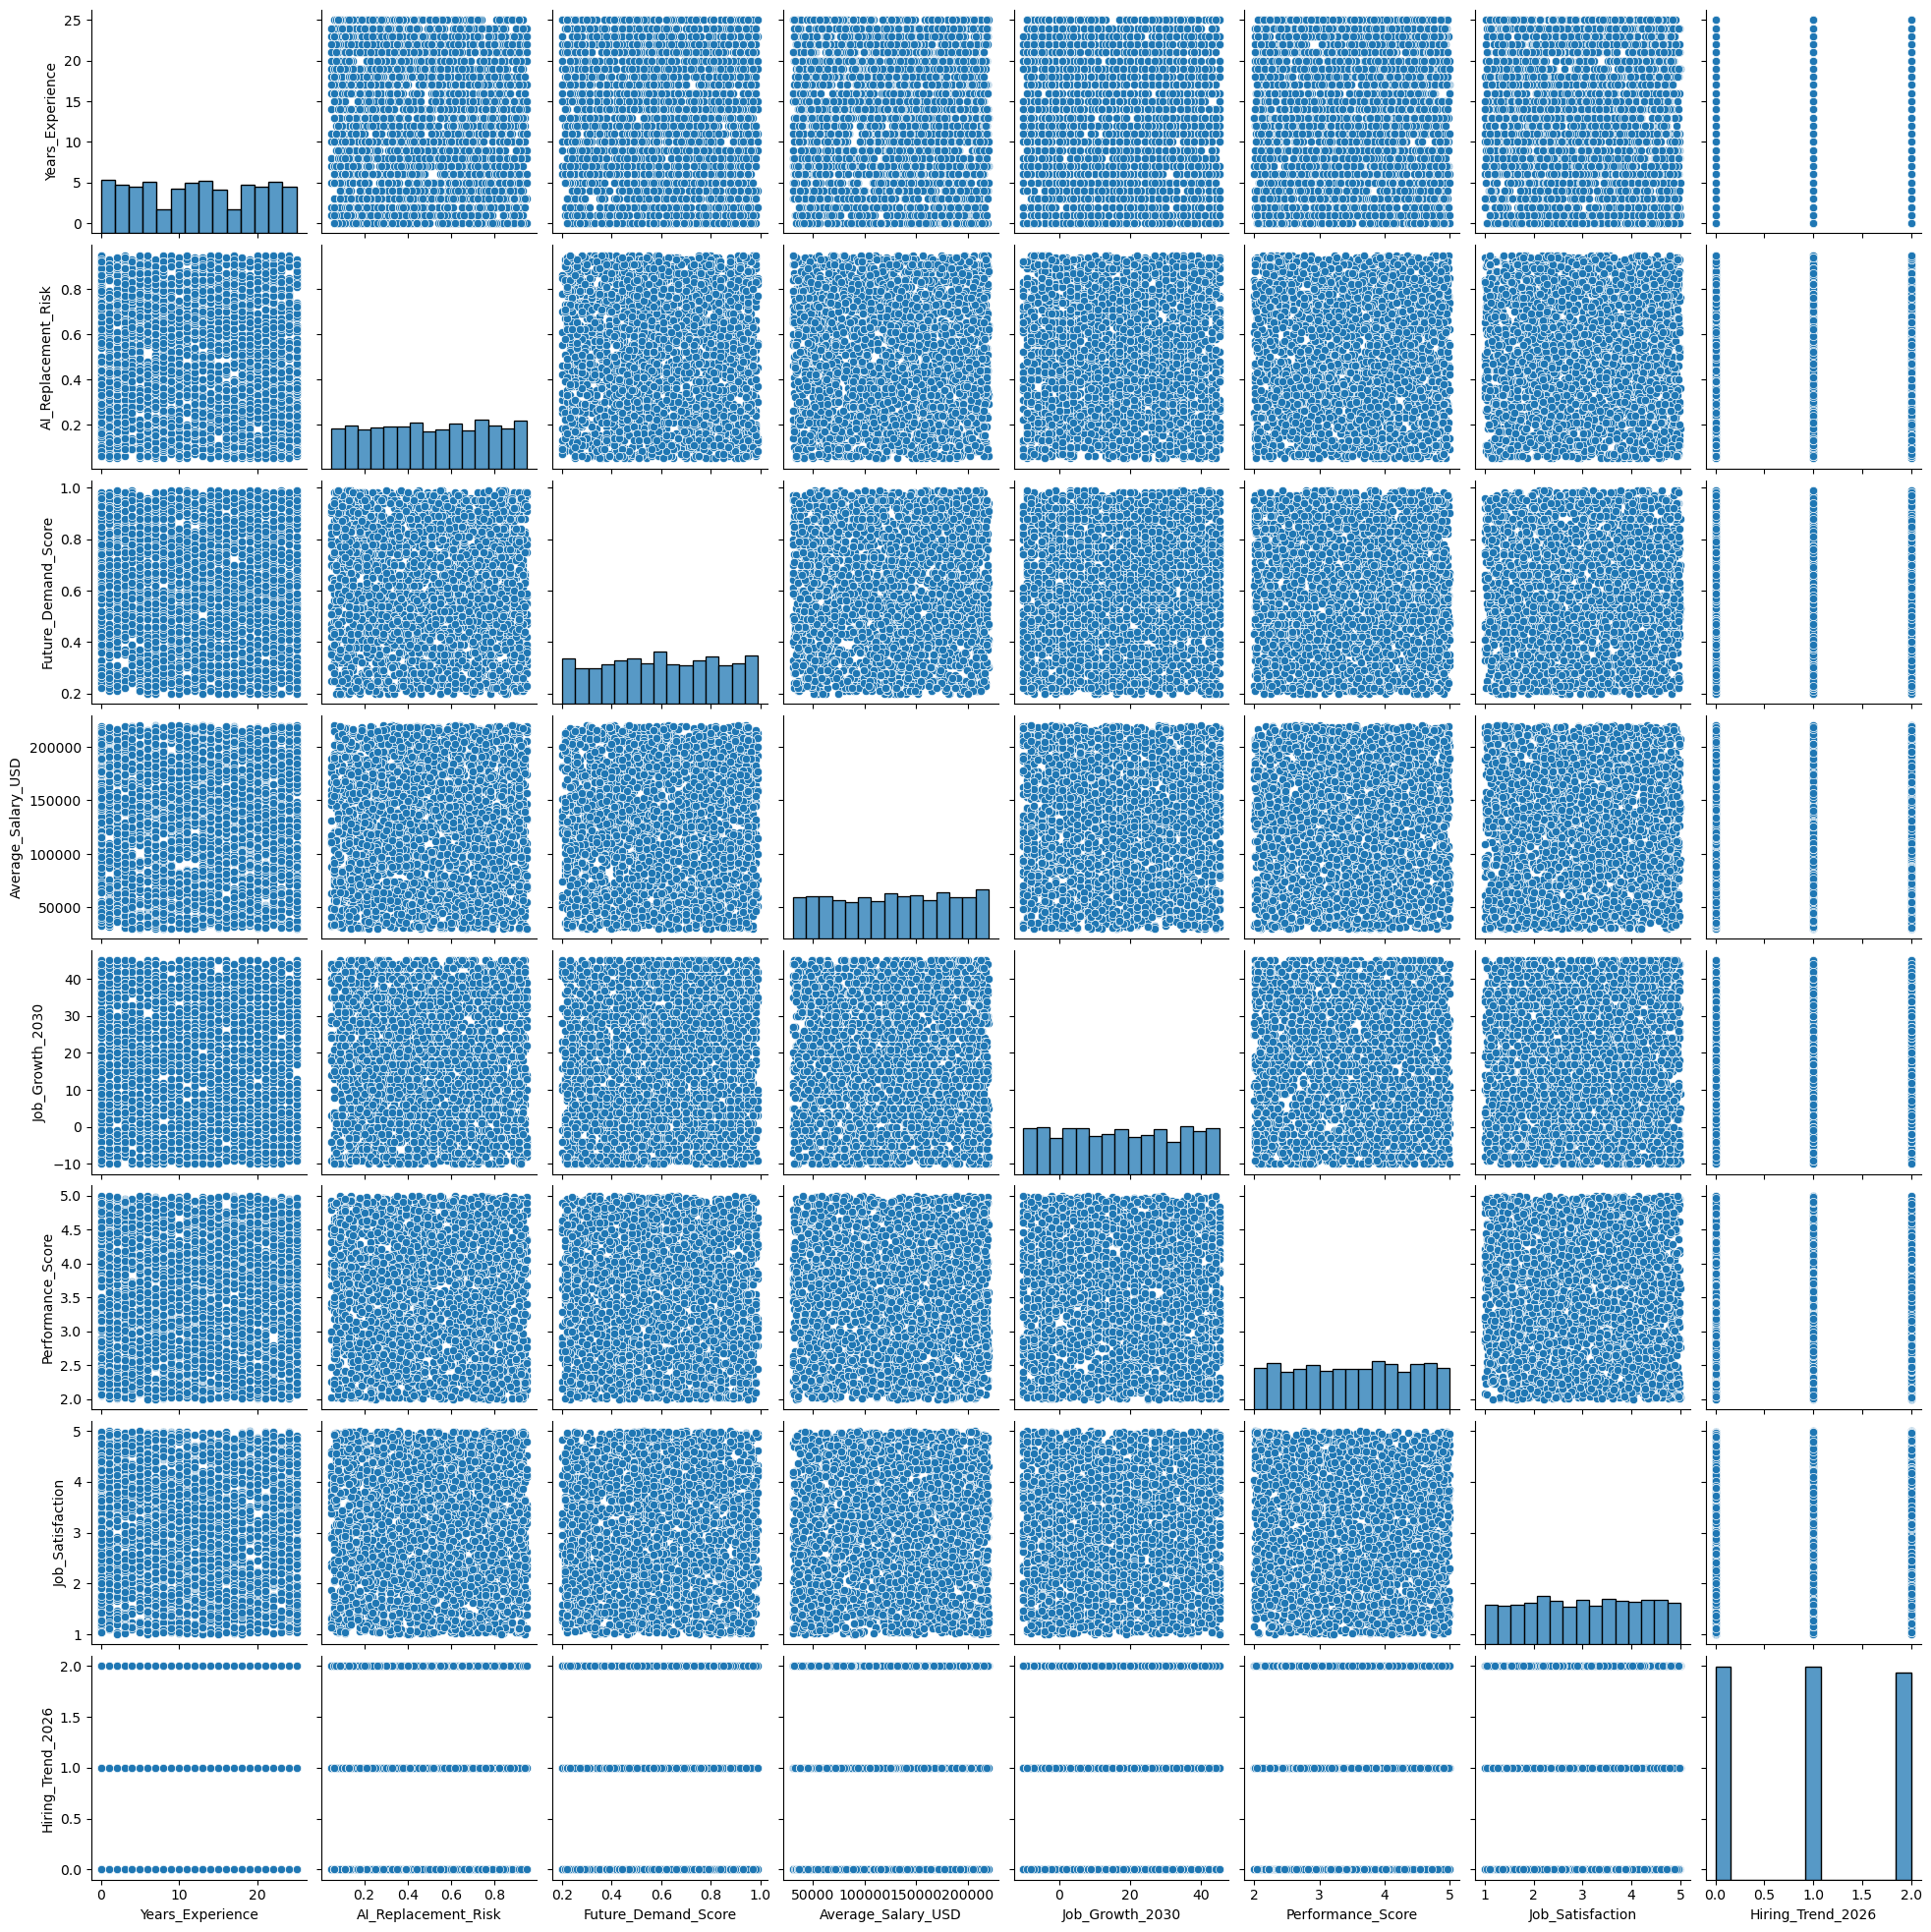

In [12]:
# Pair Plot

sns.pairplot(df.select_dtypes(include = 'number'))
plt.show()

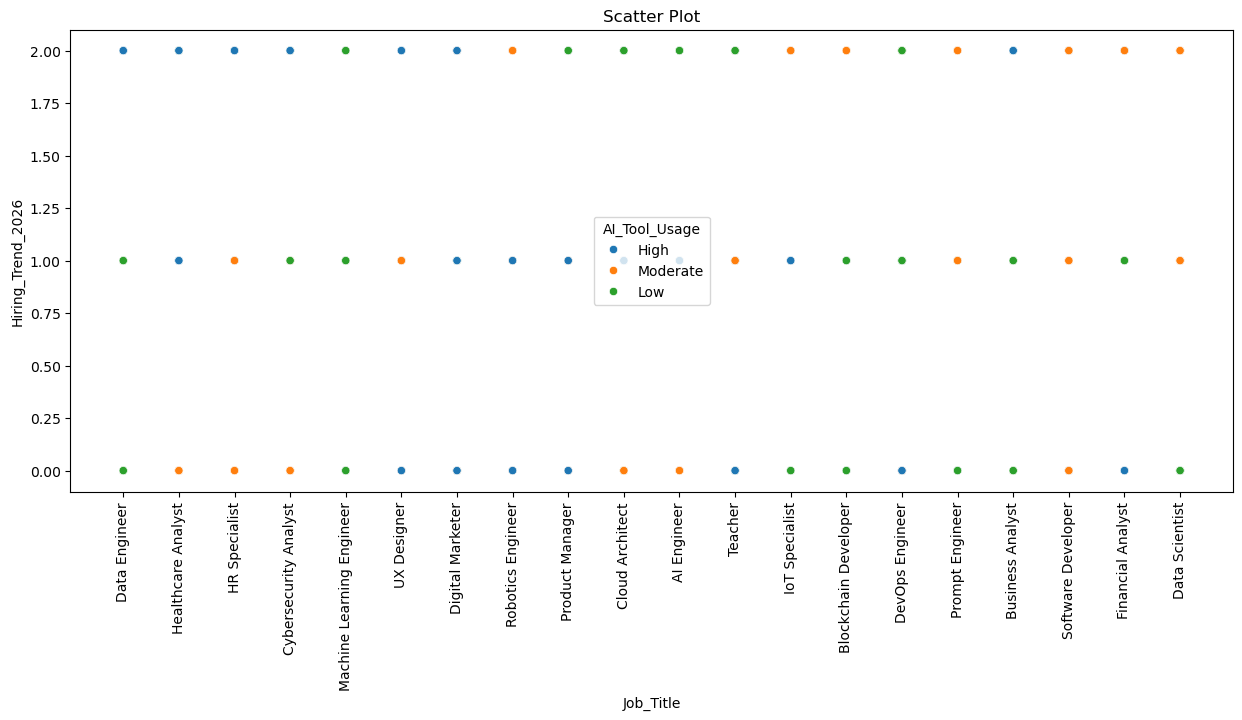

In [13]:
# Scatter Plot

plt.figure(figsize=(15, 6))
sns.scatterplot(x='Job_Title', y='Hiring_Trend_2026', hue='AI_Tool_Usage', data=df)
plt.xticks(rotation=90)
plt.title('Scatter Plot')
plt.show()

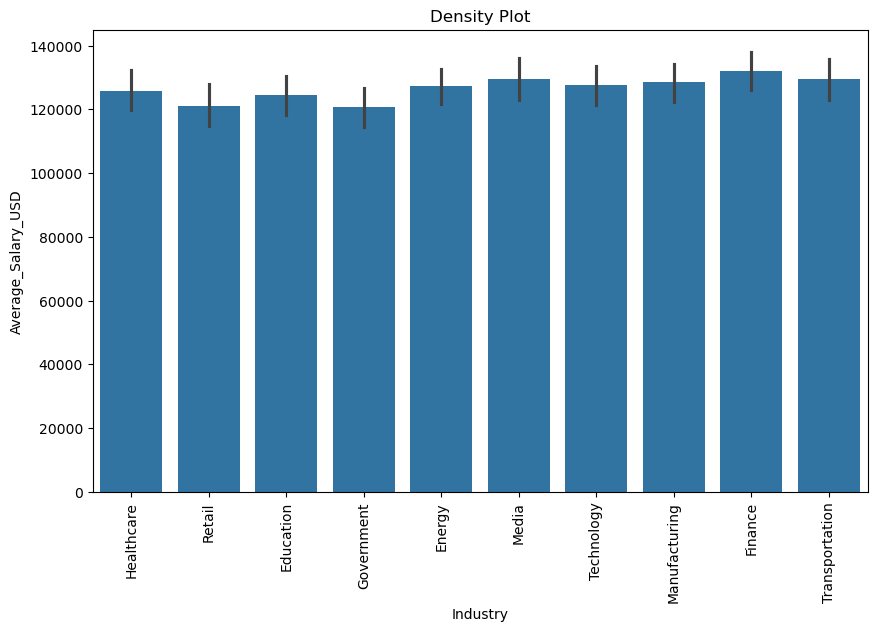

In [17]:
# Bar Plot

plt.figure(figsize=(10,6))
sns.barplot(x='Industry', y='Average_Salary_USD', data=df)
plt.title("Density Plot")
plt.xticks(rotation=90)
plt.show()

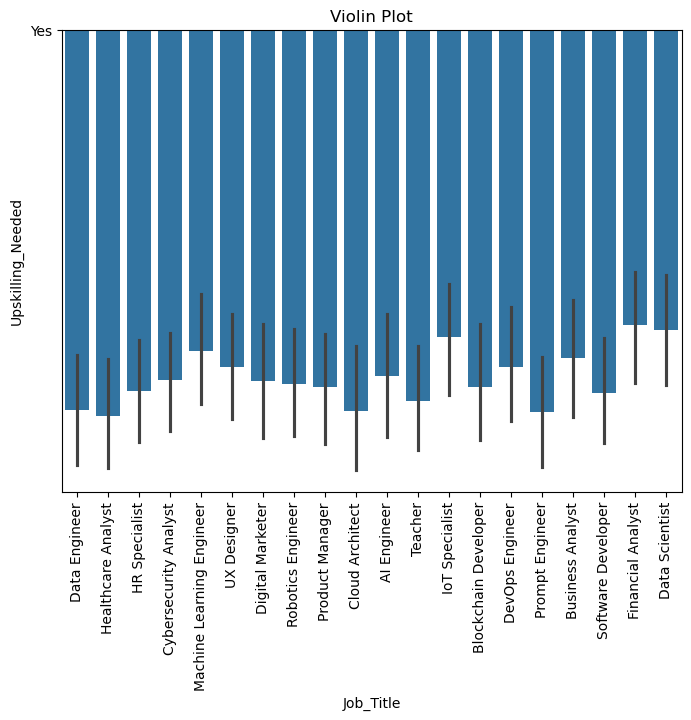

In [20]:
# Violin PLot

plt.figure(figsize=(8, 6))
sns.barplot(x='Job_Title', y='Upskilling_Needed', data=df)
plt.title('Violin Plot')
plt.xticks(rotation=90)
plt.show()

In [23]:
df.head()

,Job_Title,Industry,Country,Education_Level,Years_Experience,AI_Replacement_Risk,Future_Demand_Score,Average_Salary_USD,Required_Skills,Automation_Level,Job_Growth_2030,Company_Size,AI_Tool_Usage,Performance_Score,Upskilling_Needed,Job_Satisfaction,Hiring_Trend_2026
0,Data Engineer,Healthcare,Japan,PhD,1,0.25,0.78,207392,"Python, Communication, Deep Learning",Low,3,Enterprise,High,2.08,Yes,3.86,0
1,Healthcare Analyst,Retail,UK,Bachelor,24,0.73,0.33,140785,"Deep Learning, Azure, Communication, TensorFlo...",Low,-5,Startup,Moderate,4.54,No,4.23,0
2,HR Specialist,Education,Canada,High School,21,0.80,0.69,124800,"Kubernetes, Cloud Computing, TensorFlow, SQL, ...",Medium,-5,Startup,Low,3.14,No,3.54,1
3,Cybersecurity Analyst,Government,UK,Bachelor,5,0.29,0.94,199878,"Excel, Kubernetes, Prompt Engineering, Leadership",Medium,7,Enterprise,High,3.67,No,4.37,2
4,Healthcare Analyst,Education,UAE,PhD,20,0.11,0.92,178682,"SQL, Leadership, TensorFlow, Cybersecurity",Low,6,Startup,High,3.68,No,3.99,1


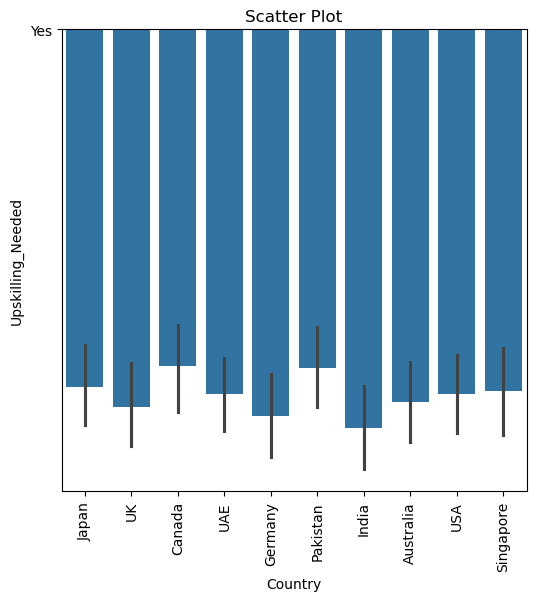

In [28]:
plt.figure(figsize=(6, 6))
sns.barplot(x='Country', y='Upskilling_Needed', data=df)
plt.title('Scatter Plot')
plt.xticks(rotation=90)
plt.show()